In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


In [3]:
data = pd.read_csv('e1_nutrients.csv')

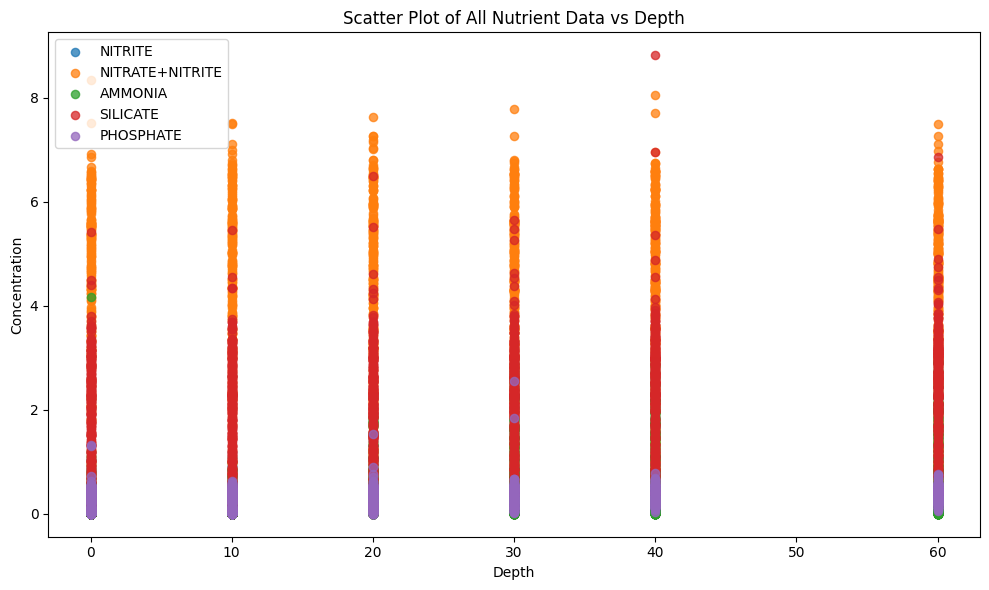

In [4]:
nutrient_cols = [c for c in data.columns if c != "Depth"]
plt.figure(figsize=(10, 6))
for col in nutrient_cols:
    plt.scatter(data["Depth"], data[col], s=35, alpha=0.75, label=col)

plt.xlabel("Depth")
plt.ylabel("Concentration")
plt.title("Scatter Plot of All Nutrient Data vs Depth")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def filter_by_column(data, column_name):
    if column_name in data.columns:
        if "Depth" not in data.columns:
            raise ValueError("Column 'Depth' does not exist in the Data.")
        
        data_new = data.copy()

        data_new = data_new.sort_values("Depth", kind="mergesort").reset_index(drop=True)

        q1 = data_new.groupby("Depth")[column_name].quantile(0.25)
        q3 = data_new.groupby("Depth")[column_name].quantile(0.75)

        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        lower_mapped = data_new["Depth"].map(lower_bound)
        upper_mapped = data_new["Depth"].map(upper_bound)

        filtered_data = data_new[
            (data_new[column_name] >= lower_mapped) & 
            (data_new[column_name] <= upper_mapped)
        ]
        
        filtered_data = filtered_data.reset_index(drop=True)
        
        return filtered_data
    
    else:
        raise ValueError(f"Column '{column_name}' does not exist in the Data.")

columns_to_clean = ['NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
clean_data = data.copy()
for col in columns_to_clean:
    clean_data = filter_by_column(clean_data, col)

print(clean_data)


      Depth  NITRITE  NITRATE+NITRITE  AMMONIA  SILICATE  PHOSPHATE
0         0     0.03             0.38     0.00      1.27       0.06
1         0     0.04             0.54     0.11      0.48       0.25
2         0     0.03             0.23     0.10      0.46       0.22
3         0     0.06             0.09     0.31      0.32       0.29
4         0     0.05             0.20     0.09      0.41       0.20
...     ...      ...              ...      ...       ...        ...
2381     60     1.29             4.28     0.31      3.44       0.28
2382     60     0.51             4.10     0.57      3.31       0.28
2383     60     0.08             4.74     0.27      2.96       0.35
2384     60     0.11             6.63     0.62      2.94       0.42
2385     60     0.15             6.10     0.85      2.78       0.41

[2386 rows x 6 columns]


In [23]:
x = clean_data.drop('NITRITE', axis=1)
y = clean_data['NITRITE']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scalar = StandardScaler()

train_mean = x_train.mean()
train_std = x_train.std(ddof=0)
x_train_scaled = (x_train - train_mean) / train_std
x_test_scaled = (x_test - train_mean) / train_std


lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)
lr_score = lr_model.score(x_test_scaled, y_test)
print(f"Linear Regression R^2 Score: {lr_score:.4f}")

rf_model = RandomForestRegressor()
rf_model.fit(x_train_scaled, y_train)
rf_score = rf_model.score(x_test_scaled, y_test)
print(f"Random Forest R^2 Score: {rf_score:.4f}")

nn_model = MLPRegressor(random_state=42, max_iter=1000)
nn_model.fit(x_train_scaled, y_train)
nn_score = nn_model.score(x_test_scaled, y_test)
print(f"Neural Network R^2 Score: {nn_score:.4f}")

sample_input = x_test_scaled.iloc[[0]]
actual_value = y_test.iloc[0]

print(f"Actual NITRITE value: {actual_value}")
print(f"Linear Regression predicted: {lr_model.predict(sample_input)[0]}")
print(f"Random Forest predicted:     {rf_model.predict(sample_input)[0]}")
print(f"Neural Network predicted:    {nn_model.predict(sample_input)[0]}")

Linear Regression R^2 Score: 0.2035
Random Forest R^2 Score: 0.4603
Neural Network R^2 Score: 0.4310
Actual NITRITE value: 0.13
Linear Regression predicted: 0.3668653004848488
Random Forest predicted:     0.17780000000000004
Neural Network predicted:    0.10814529992949377
